In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [262]:
df = pd.read_csv('data/datasets/pima_indians_diabetes_with_header.csv')

In [263]:
# Loop untuk menghitung dan mencetak rata-rata per grup
for col in df.columns:
    mean_outcome = df.groupby('Outcome')[col].mean()
    print(f"\nRata-rata {col}:")
    print(f'{mean_outcome}')



Rata-rata Pregnancies:
Outcome
0   3.30
1   4.87
Name: Pregnancies, dtype: float64

Rata-rata Glucose:
Outcome
0   109.98
1   141.26
Name: Glucose, dtype: float64

Rata-rata BloodPressure:
Outcome
0   68.18
1   70.82
Name: BloodPressure, dtype: float64

Rata-rata SkinThickness:
Outcome
0   19.66
1   22.16
Name: SkinThickness, dtype: float64

Rata-rata Insulin:
Outcome
0    68.79
1   100.34
Name: Insulin, dtype: float64

Rata-rata BMI:
Outcome
0   30.30
1   35.14
Name: BMI, dtype: float64

Rata-rata DiabetesPedigreeFunction:
Outcome
0   0.43
1   0.55
Name: DiabetesPedigreeFunction, dtype: float64

Rata-rata Age:
Outcome
0   31.19
1   37.07
Name: Age, dtype: float64

Rata-rata Outcome:
Outcome
0   0.00
1   1.00
Name: Outcome, dtype: float64


In [295]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Simpan label aktual
labels_aktual = df['Outcome']

# Drop label dari fitur
X = df.drop(columns=['Outcome'])

# Normalisasi dengan RobustScaler
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# # Beri bobot lebih pada fitur Insulin (misal 5x)
# X_scaled['Insulin'] = X_scaled['Insulin'] * 1.5


In [296]:
from sklearn.cluster import KMeans

# Jalankan KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels_pred = kmeans.labels_
# Jika cluster 0 ternyata cocok dengan label 1, kita balik
labels_pred_fix = 1 - labels_pred



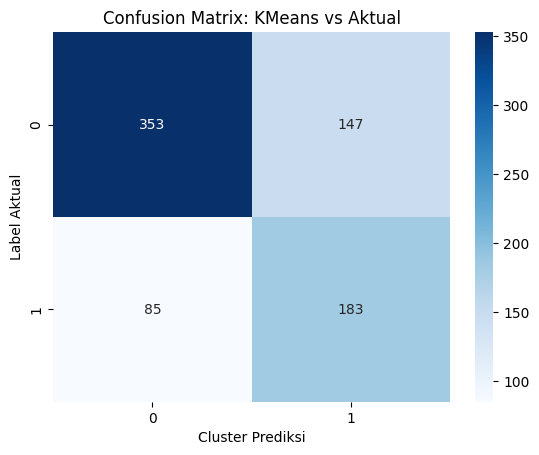

Akurasi KMeans (Cluster 0=Label 0): 0.30
Akurasi KMeans (Cluster 0=Label 1): 0.70


In [297]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(labels_aktual, labels_pred_fix)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Cluster Prediksi")
plt.ylabel("Label Aktual")
plt.title("Confusion Matrix: KMeans vs Aktual")
plt.show()

# Karena cluster bisa tertukar (0 ↔ 1), kita cek dua kemungkinan akurasi
acc1 = accuracy_score(labels_aktual, labels_pred)
acc2 = accuracy_score(labels_aktual, 1 - labels_pred)
print(f"Akurasi KMeans (Cluster 0=Label 0): {acc1:.2f}")
print(f"Akurasi KMeans (Cluster 0=Label 1): {acc2:.2f}")


In [298]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(labels_aktual, labels_pred_fix)
precision = precision_score(labels_aktual, labels_pred_fix)
recall = recall_score(labels_aktual, labels_pred_fix)
f1 = f1_score(labels_aktual, labels_pred_fix)

print(f"Akurasi : {accuracy:.2f}")
print(f"Presisi : {precision:.2f}")
print(f"Recall  : {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Akurasi : 0.70
Presisi : 0.55
Recall  : 0.68
F1 Score: 0.61


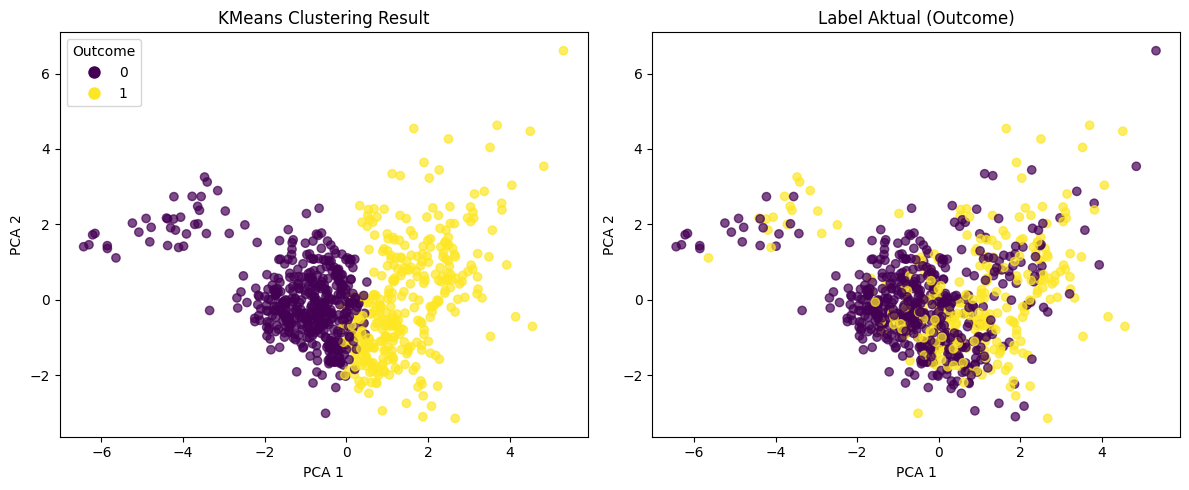

In [303]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# Reduksi dimensi ke 2D untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi hasil cluster KMeans
plt.figure(figsize=(12, 5))

# Plot berdasarkan hasil cluster
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pred_fix, cmap='viridis', alpha=0.7)
plt.title('KMeans Clustering Result')
# Tambahkan legend untuk Outcome
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='0', markerfacecolor=plt.cm.viridis(0.0), markersize=10),
    Line2D([0], [0], marker='o', color='w', label='1', markerfacecolor=plt.cm.viridis(1.0), markersize=10)
]
plt.legend(handles=legend_elements, title='Outcome')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Plot berdasarkan label aktual
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_aktual, cmap='viridis', alpha=0.7)
plt.title('Label Aktual (Outcome)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.tight_layout()
plt.show()


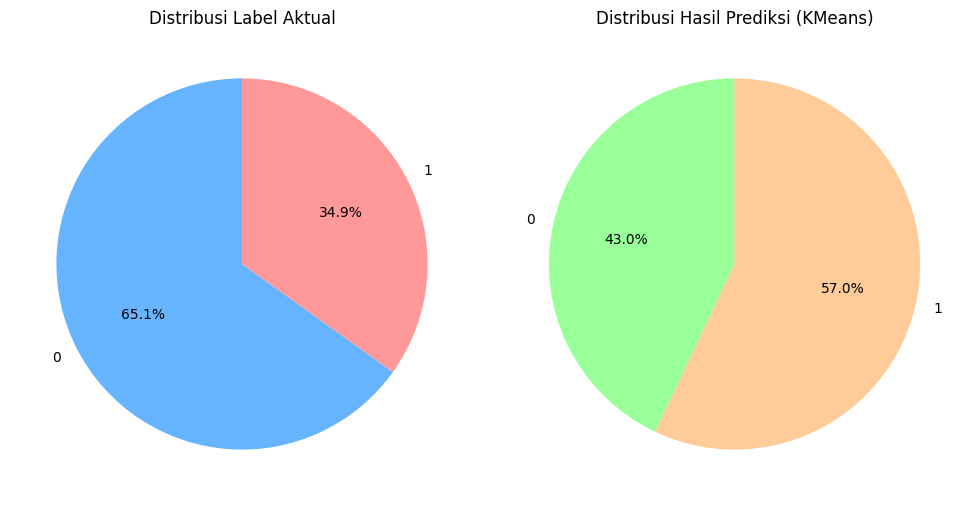

In [327]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat DataFrame gabungan
df_compare = pd.DataFrame({
    'Actual': labels_aktual,
    'Predicted': labels_pred
})

# Hitung distribusi
actual_counts = df_compare['Actual'].value_counts().sort_index()
pred_counts = df_compare['Predicted'].value_counts().sort_index()

# Pie Chart
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].pie(actual_counts, labels=actual_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
ax[0].set_title("Distribusi Label Aktual")

ax[1].pie(pred_counts, labels=pred_counts.index, autopct='%1.1f%%', startangle=90, colors=['#99ff99','#ffcc99'])
ax[1].set_title("Distribusi Hasil Prediksi (KMeans)")

plt.tight_layout()
plt.show()


In [305]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, labels_pred_fix)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.35


# CLUSTER

In [306]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Ambil hanya fitur numerik
X = df.select_dtypes(include='number')

# Optional: drop kolom 'Outcome' jika masih ada
X = X.drop(columns='Outcome', errors='ignore')

# Standarisasi
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


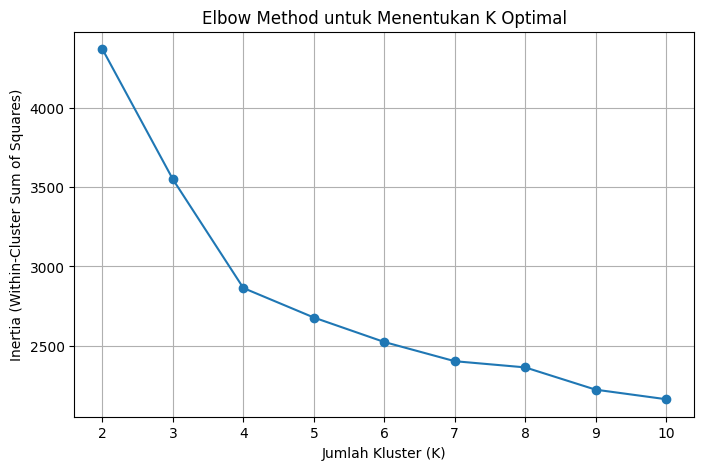

In [307]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Kluster (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.grid(True)
plt.show()


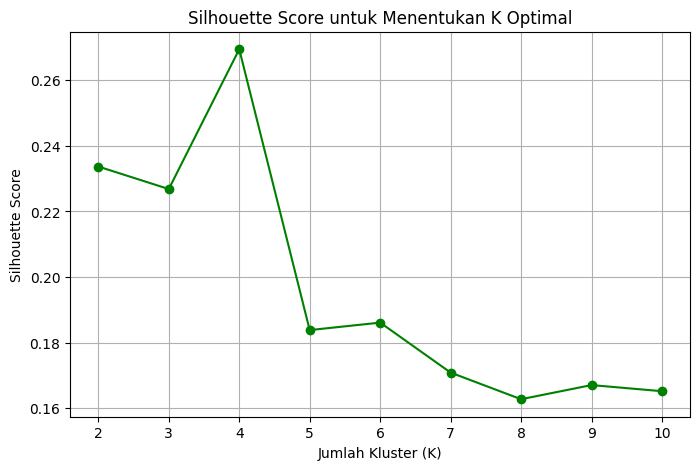

In [310]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Jumlah Kluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan K Optimal')
plt.grid(True)
plt.show()


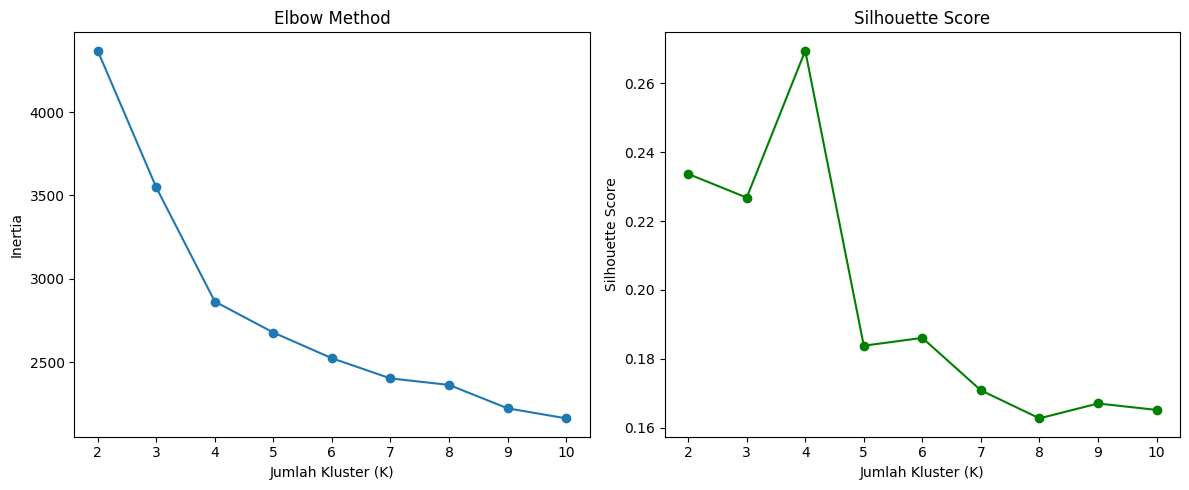

In [311]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Elbow Plot
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Jumlah Kluster (K)')
ax[0].set_ylabel('Inertia')

# Silhouette Plot
ax[1].plot(K_range, silhouette_scores, marker='o', color='green')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Jumlah Kluster (K)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [312]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [313]:
df['Cluster'].value_counts().sort_index()


Cluster
0    147
1    360
2    225
3     36
Name: count, dtype: int64

In [314]:
df.groupby('Cluster').mean(numeric_only=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PCA1,PCA2
Cluster,,,,,,,,,,,
0,3.40,148.99,74.56,32.82,248.84,36.98,0.70,33.10,0.61,1.31,1.14
1,2.15,103.41,67.41,20.88,52.48,30.24,0.42,26.27,0.14,-0.50,-0.04
2,6.89,131.13,79.21,14.92,25.73,32.53,0.43,44.93,0.50,0.47,-0.92
3,3.56,117.00,0.67,2.00,0.69,25.76,0.39,30.44,0.44,-3.33,1.42


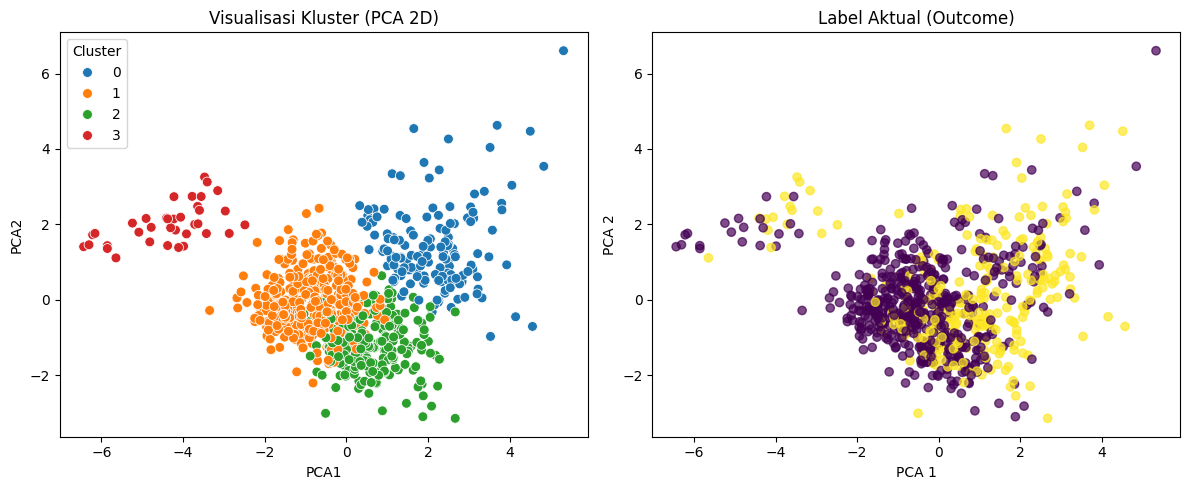

In [315]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Mulai satu figure untuk 2 subplot
plt.figure(figsize=(12, 5))

# Plot kluster prediksi
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=50)
plt.title('Visualisasi Kluster (PCA 2D)')

# Plot label aktual
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_aktual, cmap='viridis', alpha=0.7)
plt.title('Label Aktual (Outcome)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Akhiri layout
plt.tight_layout()
plt.show()


In [316]:
# Tabel count Outcome per Cluster
outcome_per_cluster = pd.crosstab(df['Cluster'], df['Outcome'])
print(outcome_per_cluster)


Outcome    0    1
Cluster          
0         58   89
1        309   51
2        113  112
3         20   16


In [326]:
# Tambahkan persentase dari total masing-masing kluster
outcome_per_cluster_pct = outcome_per_cluster.div(outcome_per_cluster.sum(axis=1), axis=0)
print(outcome_per_cluster_pct.round(2))


Outcome    0    1
Cluster          
0       0.39 0.61
1       0.86 0.14
2       0.50 0.50
3       0.56 0.44


In [317]:
# Pastikan kolom 'Cluster' sudah ada di df
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

# Tampilkan tabel
print(cluster_summary)


         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
Cluster                                                                      
0               3.40   148.99          74.56          32.82   248.84 36.98   
1               2.15   103.41          67.41          20.88    52.48 30.24   
2               6.89   131.13          79.21          14.92    25.73 32.53   
3               3.56   117.00           0.67           2.00     0.69 25.76   

         DiabetesPedigreeFunction   Age  Outcome  PCA1  PCA2  
Cluster                                                       
0                            0.70 33.10     0.61  2.15  1.39  
1                            0.42 26.27     0.14 -0.85 -0.04  
2                            0.43 44.93     0.50  0.66 -1.16  
3                            0.39 30.44     0.44 -4.37  2.01  


In [318]:
pd.options.display.float_format = '{:.2f}'.format
print(cluster_summary)


         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
Cluster                                                                      
0               3.40   148.99          74.56          32.82   248.84 36.98   
1               2.15   103.41          67.41          20.88    52.48 30.24   
2               6.89   131.13          79.21          14.92    25.73 32.53   
3               3.56   117.00           0.67           2.00     0.69 25.76   

         DiabetesPedigreeFunction   Age  Outcome  PCA1  PCA2  
Cluster                                                       
0                            0.70 33.10     0.61  2.15  1.39  
1                            0.42 26.27     0.14 -0.85 -0.04  
2                            0.43 44.93     0.50  0.66 -1.16  
3                            0.39 30.44     0.44 -4.37  2.01  


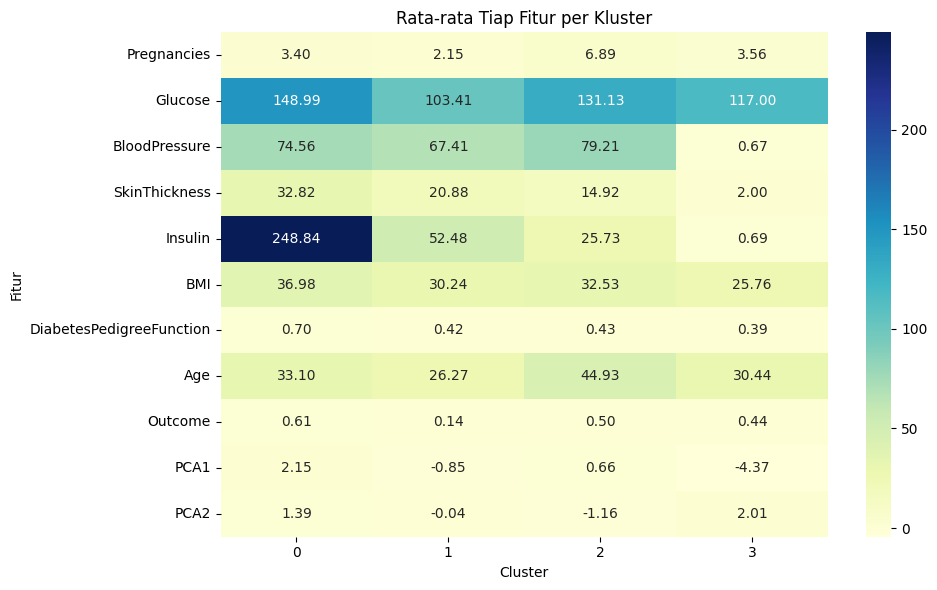

In [319]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Rata-rata Tiap Fitur per Kluster')
plt.xlabel('Cluster')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


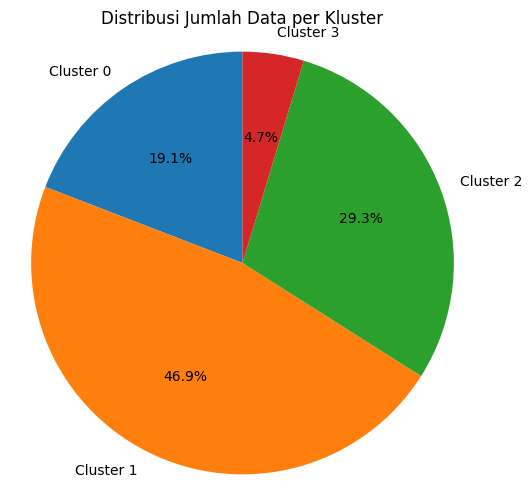

In [320]:
import matplotlib.pyplot as plt

# Hitung jumlah data per kluster
cluster_counts = df['Cluster'].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=90, colors=plt.cm.tab10.colors)
plt.title('Distribusi Jumlah Data per Kluster')
plt.axis('equal')
plt.show()


In [321]:
# Ambil mean per fitur per kluster
cluster_means = df.groupby('Cluster').mean(numeric_only=True)

# Hitung range antar kluster (max - min) untuk tiap fitur
feature_influence = cluster_means.max() - cluster_means.min()

# Urutkan dari pengaruh tertinggi
influential_features = feature_influence.sort_values(ascending=False)
print(influential_features)


Insulin                    248.14
BloodPressure               78.54
Glucose                     45.58
SkinThickness               30.82
Age                         18.66
BMI                         11.22
PCA1                         6.51
Pregnancies                  4.74
PCA2                         3.17
Outcome                      0.46
DiabetesPedigreeFunction     0.31
dtype: float64


C:\Users\71486\AppData\Local\Temp\ipykernel_19420\1747640564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=influential_features.values, y=influential_features.index, palette='viridis')


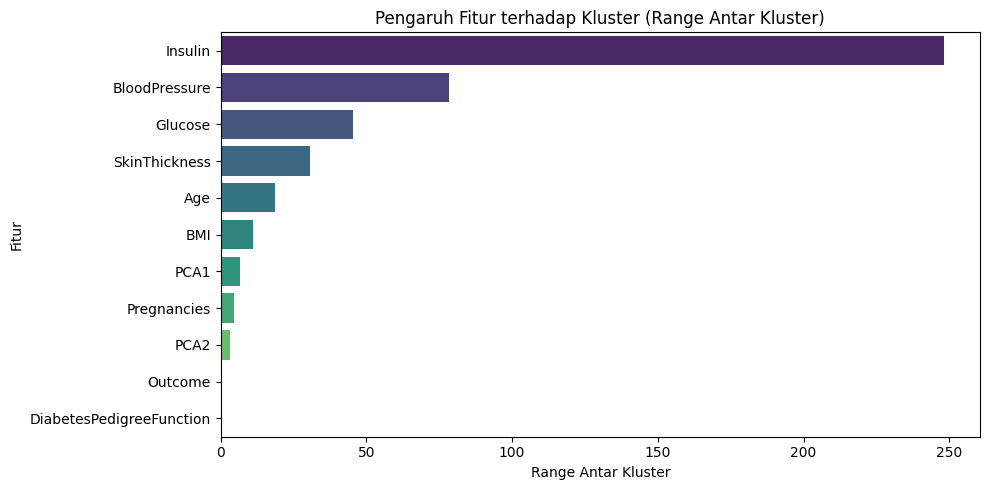

In [322]:
plt.figure(figsize=(10, 5))
sns.barplot(x=influential_features.values, y=influential_features.index, palette='viridis')
plt.title('Pengaruh Fitur terhadap Kluster (Range Antar Kluster)')
plt.xlabel('Range Antar Kluster')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


In [323]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
 9   Cluster                   768 non-null    int32  
 10  PCA1                      768 non-null    float64
 11  PCA2                      768 non-null    float64
dtypes: float64(4), int32(1), int64(7)
memory usage: 69.1 KB


In [324]:
# Misal Cluster 0 dan 2 adalah positif (label 1)
clusters_as_1 = [0, 1]

# Buat prediksi label berdasarkan kluster
labels_pred_fix = df['Cluster'].apply(lambda x: 1 if x in clusters_as_1 else 0)
